Parsed progress rows: 30


,step,total_steps,epoch,progress_percent,loss,grad_norm,learning_rate,elapsed_min,eta_min
0,1,30,0.1,3.33,0.618052,8.1250,0.000000,1.05,30.52
1,2,30,0.2,6.67,0.582330,6.5938,0.000020,2.01,28.17
2,3,30,0.3,10.00,0.676530,9.1250,0.000019,2.93,26.38
3,4,30,0.4,13.33,0.580712,4.3438,0.000019,3.85,25.03
4,5,30,0.5,16.67,0.527747,3.4062,0.000018,4.67,23.35


,step,total_steps,epoch,progress_percent,loss,grad_norm,learning_rate,elapsed_min,eta_min
25,26,30,2.6,86.67,0.348177,2.0625,3.448000e-06,24.90,3.83
26,27,30,2.7,90.00,0.349865,1.9531,2.759000e-06,25.82,2.87
27,28,30,2.8,93.33,0.378538,2.3125,2.069000e-06,26.61,1.90
28,29,30,2.9,96.67,0.336017,1.9688,1.379000e-06,27.32,0.94
29,30,30,3.0,100.00,0.334230,2.0156,6.897000e-07,28.24,0.00


Training runs:


,timestamp,model_id,sat_train_rows,unsat_train_rows,total_train_rows,num_train_epochs,per_device_train_batch_size,gradient_accumulation_steps,learning_rate,max_length,last_checkpoint,final_train_loss,train_runtime,train_samples_per_second,train_steps_per_second
0,2026-05-05 00:19:25,Qwen/Qwen3.5-0.8B-Base,80,80,160,3.0,1,8,0.00002,4096,NaN,0.440778,1700.4237,0.282,0.018


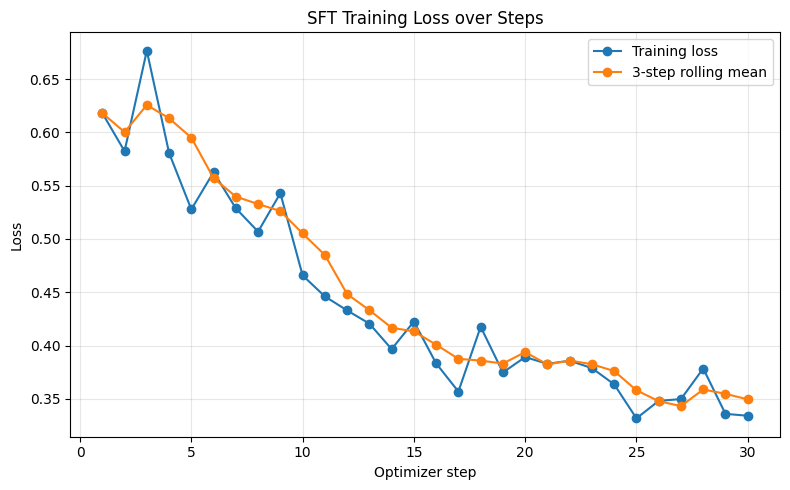

Saved: results/sft_training_plots/sft_training_loss.png


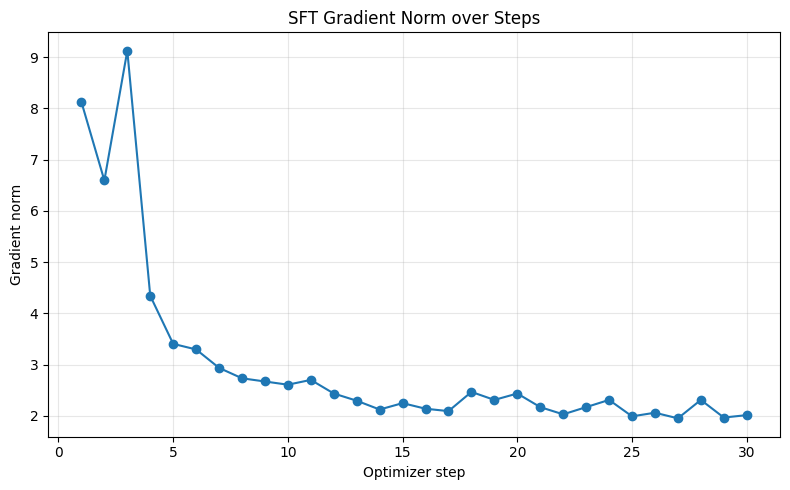

Saved: results/sft_training_plots/sft_gradient_norm.png


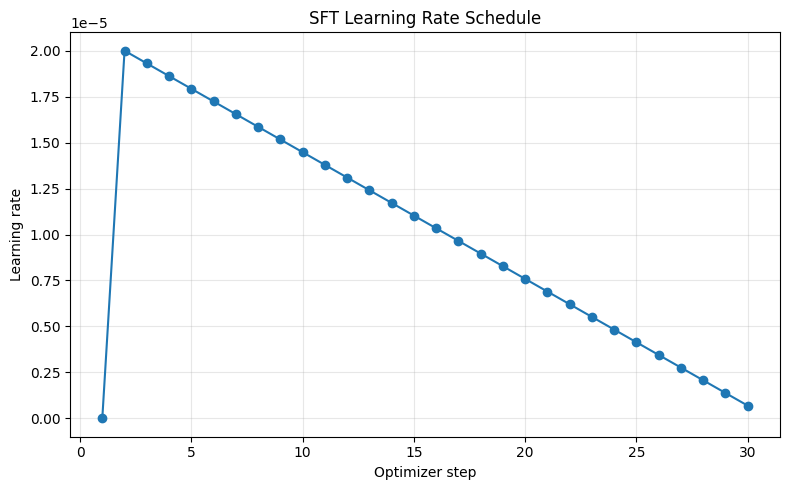

Saved: results/sft_training_plots/sft_learning_rate.png

Training summary:
{
  "model_id": "Qwen/Qwen3.5-0.8B-Base",
  "sat_train_rows": 80,
  "unsat_train_rows": 80,
  "total_train_rows": 160,
  "epochs": 3.0,
  "effective_batch_size": 8,
  "learning_rate": 2e-05,
  "max_length": 4096,
  "final_train_loss": 0.4407783091068268,
  "train_runtime_min": 28.340395,
  "train_samples_per_second": 0.282,
  "train_steps_per_second": 0.018
}
Saved: results/sft_training_plots/sft_training_summary.json
Saved: results/sft_training_plots/parsed_sft_training_progress.csv


In [5]:
import re
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. File paths
# ============================================================

# Change these paths if your files are in a different folder.
TRAINING_RUNS_CSV = Path("/scratch/network/yd1202/COS598B-project/results/sft_qwen35_08b_base_sat_unsat_full/training_runs.csv")
TRAINING_LOG = Path("nohup_sft_training.out")

OUTPUT_DIR = Path("results/sft_training_plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Helper: clean ANSI characters from log
# ============================================================

def clean_ansi(text: str) -> str:
    """Remove ANSI escape sequences and carriage returns from terminal logs."""
    ansi_escape = re.compile(r"\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])")
    text = ansi_escape.sub("", text)
    text = text.replace("\r", "\n")
    return text


# ============================================================
# 3. Parse progress lines from nohup_sft_training.out
# ============================================================

def parse_training_log(log_path: Path) -> pd.DataFrame:
    raw_text = log_path.read_text(encoding="utf-8", errors="ignore")
    text = clean_ansi(raw_text)

    rows = []

    # Example line:
    # [progress] step=1/30 | epoch=0.1000 | progress=3.33% | loss=0.618052
    # | grad_norm=8.1250 | lr=0.000e+00 | elapsed=1.05 min | eta=30.52 min
    progress_pattern = re.compile(
        r"\[progress\]\s+"
        r"step=(?P<step>\d+)/(?P<total_steps>\d+)\s+\|\s+"
        r"epoch=(?P<epoch>[0-9.]+)\s+\|\s+"
        r"progress=(?P<progress>[0-9.]+)%"
        r"(?:\s+\|\s+loss=(?P<loss>[0-9.eE+-]+))?"
        r"(?:\s+\|\s+grad_norm=(?P<grad_norm>[0-9.eE+-]+))?"
        r"(?:\s+\|\s+lr=(?P<lr>[0-9.eE+-]+))?"
        r"(?:\s+\|\s+elapsed=(?P<elapsed_min>[0-9.eE+-]+)\s+min)?"
        r"(?:\s+\|\s+eta=(?P<eta_min>[0-9.eE+-]+)\s+min)?"
    )

    for match in progress_pattern.finditer(text):
        item = match.groupdict()

        def to_float(x):
            return float(x) if x not in [None, ""] else None

        rows.append({
            "step": int(item["step"]),
            "total_steps": int(item["total_steps"]),
            "epoch": to_float(item["epoch"]),
            "progress_percent": to_float(item["progress"]),
            "loss": to_float(item["loss"]),
            "grad_norm": to_float(item["grad_norm"]),
            "learning_rate": to_float(item["lr"]),
            "elapsed_min": to_float(item["elapsed_min"]),
            "eta_min": to_float(item["eta_min"]),
        })

    df = pd.DataFrame(rows)

    # Drop duplicate final progress lines if they repeat the same step without loss.
    if not df.empty:
        df = df.sort_values(["step", "loss"], na_position="last")
        df = df.drop_duplicates(subset=["step"], keep="first")
        df = df.sort_values("step").reset_index(drop=True)

    return df


progress_df = parse_training_log(TRAINING_LOG)

print("Parsed progress rows:", len(progress_df))
display(progress_df.head())
display(progress_df.tail())


# ============================================================
# 4. Load final run summary from training_runs.csv
# ============================================================

runs_df = pd.read_csv(TRAINING_RUNS_CSV)

print("Training runs:")
display(runs_df)

# Convert useful columns to numeric.
numeric_cols = [
    "sat_train_rows",
    "unsat_train_rows",
    "total_train_rows",
    "num_train_epochs",
    "per_device_train_batch_size",
    "gradient_accumulation_steps",
    "learning_rate",
    "max_length",
    "final_train_loss",
    "train_runtime",
    "train_samples_per_second",
    "train_steps_per_second",
]

for col in numeric_cols:
    if col in runs_df.columns:
        runs_df[col] = pd.to_numeric(runs_df[col], errors="coerce")


# ============================================================
# 5. Plot 1: Training loss over optimizer steps
# ============================================================

loss_df = progress_df.dropna(subset=["loss"]).copy()

plt.figure(figsize=(8, 5))
plt.plot(loss_df["step"], loss_df["loss"], marker="o", label="Training loss")

if len(loss_df) >= 3:
    loss_df["loss_rolling"] = loss_df["loss"].rolling(window=3, min_periods=1).mean()
    plt.plot(loss_df["step"], loss_df["loss_rolling"], marker="o", label="3-step rolling mean")

plt.xlabel("Optimizer step")
plt.ylabel("Loss")
plt.title("SFT Training Loss over Steps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_plot_path = OUTPUT_DIR / "sft_training_loss.png"
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved:", loss_plot_path)


# ============================================================
# 6. Plot 2: Gradient norm over optimizer steps
# ============================================================

grad_df = progress_df.dropna(subset=["grad_norm"]).copy()

plt.figure(figsize=(8, 5))
plt.plot(grad_df["step"], grad_df["grad_norm"], marker="o")
plt.xlabel("Optimizer step")
plt.ylabel("Gradient norm")
plt.title("SFT Gradient Norm over Steps")
plt.grid(True, alpha=0.3)
plt.tight_layout()

grad_plot_path = OUTPUT_DIR / "sft_gradient_norm.png"
plt.savefig(grad_plot_path, dpi=200)
plt.show()

print("Saved:", grad_plot_path)


# ============================================================
# 7. Plot 3: Learning rate schedule
# ============================================================

lr_df = progress_df.dropna(subset=["learning_rate"]).copy()

plt.figure(figsize=(8, 5))
plt.plot(lr_df["step"], lr_df["learning_rate"], marker="o")
plt.xlabel("Optimizer step")
plt.ylabel("Learning rate")
plt.title("SFT Learning Rate Schedule")
plt.grid(True, alpha=0.3)
plt.tight_layout()

lr_plot_path = OUTPUT_DIR / "sft_learning_rate.png"
plt.savefig(lr_plot_path, dpi=200)
plt.show()

print("Saved:", lr_plot_path)


# # ============================================================
# # 8. Plot 4: Elapsed time over optimizer steps
# # ============================================================

# time_df = progress_df.dropna(subset=["elapsed_min"]).copy()

# plt.figure(figsize=(8, 5))
# plt.plot(time_df["step"], time_df["elapsed_min"], marker="o")
# plt.xlabel("Optimizer step")
# plt.ylabel("Elapsed time (minutes)")
# plt.title("SFT Training Time Progress")
# plt.grid(True, alpha=0.3)
# plt.tight_layout()

# time_plot_path = OUTPUT_DIR / "sft_elapsed_time.png"
# plt.savefig(time_plot_path, dpi=200)
# plt.show()

# print("Saved:", time_plot_path)


# # ============================================================
# # 9. Plot 5: Loss by epoch
# # ============================================================

# plt.figure(figsize=(8, 5))
# plt.plot(loss_df["epoch"], loss_df["loss"], marker="o", label="Training loss")

# if "loss_rolling" in loss_df.columns:
#     plt.plot(loss_df["epoch"], loss_df["loss_rolling"], marker="o", label="3-step rolling mean")

# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("SFT Training Loss by Epoch")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()

# epoch_loss_plot_path = OUTPUT_DIR / "sft_loss_by_epoch.png"
# plt.savefig(epoch_loss_plot_path, dpi=200)
# plt.show()

# print("Saved:", epoch_loss_plot_path)


# # ============================================================
# # 10. Plot 6: Dataset composition
# # ============================================================

# latest_run = runs_df.iloc[-1]

# dataset_counts = pd.Series({
#     "SAT train": latest_run.get("sat_train_rows", 0),
#     "UNSAT train": latest_run.get("unsat_train_rows", 0),
# })

# plt.figure(figsize=(6, 5))
# dataset_counts.plot(kind="bar")
# plt.xlabel("Training subset")
# plt.ylabel("Number of examples")
# plt.title("SFT Training Dataset Composition")
# plt.xticks(rotation=0)
# plt.grid(True, axis="y", alpha=0.3)
# plt.tight_layout()

# dataset_plot_path = OUTPUT_DIR / "sft_dataset_composition.png"
# plt.savefig(dataset_plot_path, dpi=200)
# plt.show()

# print("Saved:", dataset_plot_path)


# ============================================================
# 11. Print concise training summary
# ============================================================

summary = {
    "model_id": latest_run.get("model_id"),
    "sat_train_rows": int(latest_run.get("sat_train_rows")),
    "unsat_train_rows": int(latest_run.get("unsat_train_rows")),
    "total_train_rows": int(latest_run.get("total_train_rows")),
    "epochs": float(latest_run.get("num_train_epochs")),
    "effective_batch_size": int(
        latest_run.get("per_device_train_batch_size")
        * latest_run.get("gradient_accumulation_steps")
    ),
    "learning_rate": float(latest_run.get("learning_rate")),
    "max_length": int(latest_run.get("max_length")),
    "final_train_loss": float(latest_run.get("final_train_loss")),
    "train_runtime_min": float(latest_run.get("train_runtime")) / 60.0,
    "train_samples_per_second": float(latest_run.get("train_samples_per_second")),
    "train_steps_per_second": float(latest_run.get("train_steps_per_second")),
}

print("\nTraining summary:")
print(json.dumps(summary, indent=2))

summary_path = OUTPUT_DIR / "sft_training_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("Saved:", summary_path)


# ============================================================
# 12. Save parsed training progress table
# ============================================================

parsed_csv_path = OUTPUT_DIR / "parsed_sft_training_progress.csv"
progress_df.to_csv(parsed_csv_path, index=False)
print("Saved:", parsed_csv_path)

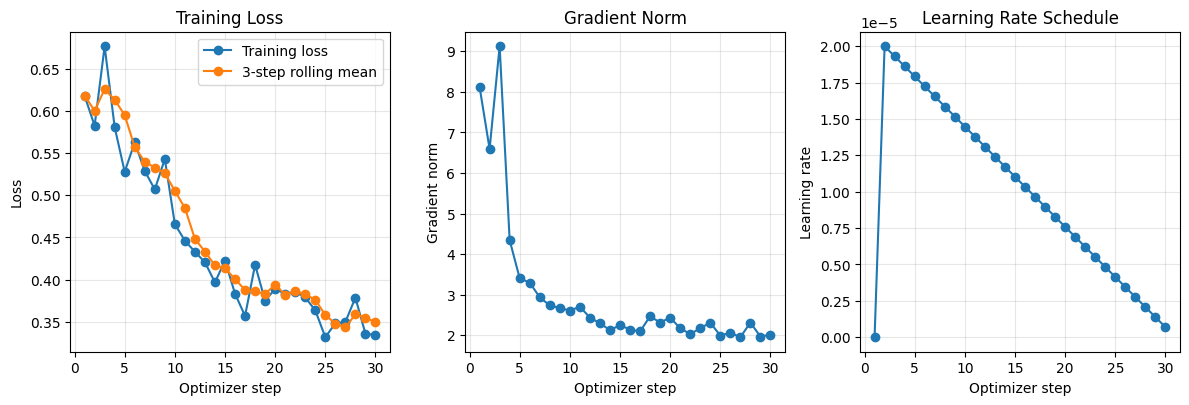

Saved: results/sft_training_plots/sft_training_three_panel.png


In [8]:
# ============================================================
# Combined plot: loss, gradient norm, and learning rate
# Three square subplots in one row
# ============================================================

loss_df = progress_df.dropna(subset=["loss"]).copy()
grad_df = progress_df.dropna(subset=["grad_norm"]).copy()
lr_df = progress_df.dropna(subset=["learning_rate"]).copy()

# Compute rolling loss if enough points
if len(loss_df) >= 3:
    loss_df["loss_rolling"] = loss_df["loss"].rolling(window=3, min_periods=1).mean()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# ----------------------------
# Subplot 1: Training loss
# ----------------------------
axes[0].plot(loss_df["step"], loss_df["loss"], marker="o", label="Training loss")

if "loss_rolling" in loss_df.columns:
    axes[0].plot(loss_df["step"], loss_df["loss_rolling"], marker="o", label="3-step rolling mean")

axes[0].set_xlabel("Optimizer step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_box_aspect(1)  # square subplot

# ----------------------------
# Subplot 2: Gradient norm
# ----------------------------
axes[1].plot(grad_df["step"], grad_df["grad_norm"], marker="o")
axes[1].set_xlabel("Optimizer step")
axes[1].set_ylabel("Gradient norm")
axes[1].set_title("Gradient Norm")
axes[1].grid(True, alpha=0.3)
axes[1].set_box_aspect(1)  # square subplot

# ----------------------------
# Subplot 3: Learning rate
# ----------------------------
axes[2].plot(lr_df["step"], lr_df["learning_rate"], marker="o")


axes[2].set_xlabel("Optimizer step")
axes[2].set_ylabel("Learning rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)  # square subplot

plt.tight_layout()

combined_plot_path = OUTPUT_DIR / "sft_training_three_panel.png"
plt.savefig(combined_plot_path, dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", combined_plot_path)

,model,overall_accuracy,sat_accuracy,unsat_accuracy
0,Base,0.500,0.0,1.00
1,SFT,0.675,0.4,0.95


,model,prediction_accuracy,certificate_validity,correct_and_valid_rate
0,Base,0.500,0.0,0.0
1,SFT,0.675,0.3,0.3


,model,SAT,UNSAT
0,Base,0,40
1,SFT,9,31


,model,sat_cert_valid_predicted_sat,unsat_cert_valid_predicted_unsat,parse_warnings
0,Base,0.000000,0.000000,40
1,SFT,0.444444,0.258065,23


<Figure size 800x500 with 0 Axes>

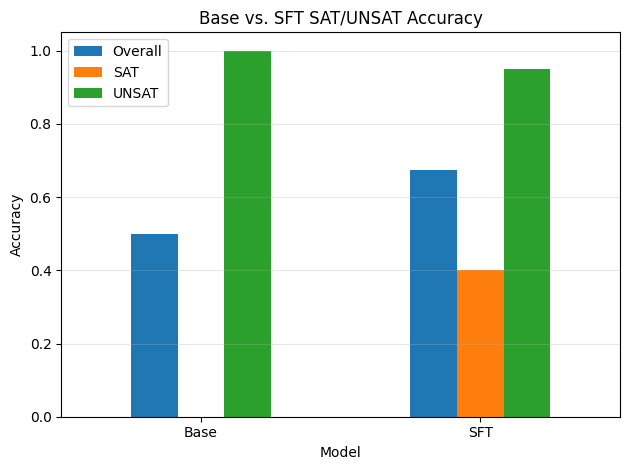

Saved: results/model_comparison_plots/base_vs_sft_accuracy.png


<Figure size 800x500 with 0 Axes>

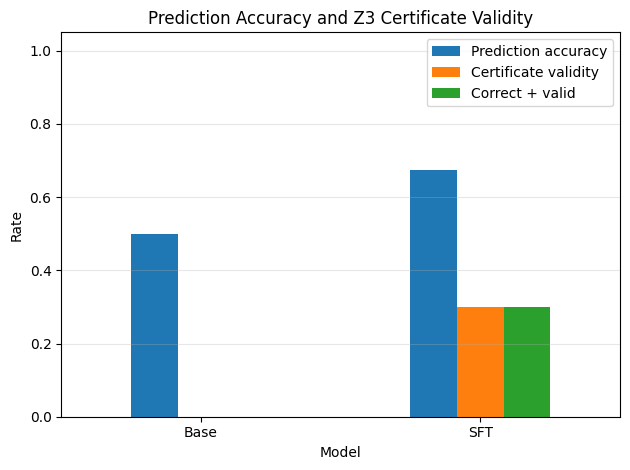

Saved: results/model_comparison_plots/base_vs_sft_z3_validity.png


<Figure size 800x500 with 0 Axes>

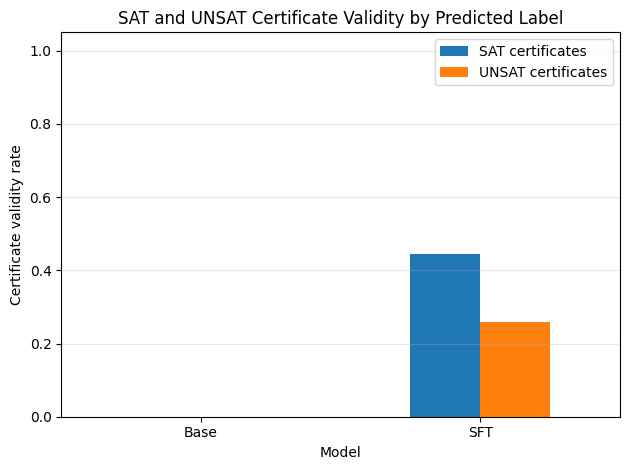

Saved: results/model_comparison_plots/base_vs_sft_sat_unsat_certificate_validity.png


,model,overall_accuracy,sat_accuracy,unsat_accuracy,prediction_accuracy,certificate_validity,correct_and_valid_rate,SAT,UNSAT,sat_cert_valid_predicted_sat,unsat_cert_valid_predicted_unsat,parse_warnings
0,Base,0.500,0.0,1.00,0.500,0.0,0.0,0,40,0.000000,0.000000,40
1,SFT,0.675,0.4,0.95,0.675,0.3,0.3,9,31,0.444444,0.258065,23


Saved: results/model_comparison_plots/base_vs_sft_comparison_table.csv


In [12]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. File paths
# ============================================================

BASE_SUMMARY_PATH = Path("results/baseline_qwen35_08b_base_results/base_qwen35_08b_base_test_summary.json")
SFT_SUMMARY_PATH = Path("results/eval_sft_qwen35_08b_full_on_test/SFT_qwen35_08b_base_test_summary_corrected.json")

BASE_Z3_PATH = Path("results/baseline_qwen35_08b_base_results/z3_certificate_validation/base_z3_certificate_validation_summary.json")
SFT_Z3_PATH = Path("results/eval_sft_qwen35_08b_full_on_test/z3_certificate_validation/SFT_z3_certificate_validation_summary.json")

OUTPUT_DIR = Path("results/model_comparison_plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Load summaries
# ============================================================

def load_json(path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


base_summary = load_json(BASE_SUMMARY_PATH)
sft_summary = load_json(SFT_SUMMARY_PATH)

base_z3 = load_json(BASE_Z3_PATH)
sft_z3 = load_json(SFT_Z3_PATH)


# ============================================================
# 3. Build comparison tables
# ============================================================

accuracy_df = pd.DataFrame([
    {
        "model": "Base",
        "overall_accuracy": base_summary["overall_accuracy"],
        "sat_accuracy": base_summary["sat_test_accuracy"],
        "unsat_accuracy": base_summary["unsat_test_accuracy"],
    },
    {
        "model": "SFT",
        "overall_accuracy": sft_summary["overall_accuracy"],
        "sat_accuracy": sft_summary["sat_test_accuracy"],
        "unsat_accuracy": sft_summary["unsat_test_accuracy"],
    },
])

z3_df = pd.DataFrame([
    {
        "model": "Base",
        "prediction_accuracy": base_z3["prediction_accuracy"],
        "certificate_validity": base_z3["certificate_validity_all_predictions"],
        "correct_and_valid_rate": base_z3["overall_correct_and_valid_rate"],
    },
    {
        "model": "SFT",
        "prediction_accuracy": sft_z3["prediction_accuracy"],
        "certificate_validity": sft_z3["certificate_validity_all_predictions"],
        "correct_and_valid_rate": sft_z3["overall_correct_and_valid_rate"],
    },
])

prediction_counts_df = pd.DataFrame([
    {
        "model": "Base",
        "SAT": base_summary["predicted_label_counts"].get("SAT", 0),
        "UNSAT": base_summary["predicted_label_counts"].get("UNSAT", 0),
    },
    {
        "model": "SFT",
        "SAT": sft_summary["predicted_label_counts"].get("SAT", 0),
        "UNSAT": sft_summary["predicted_label_counts"].get("UNSAT", 0),
    },
])

z3_detail_df = pd.DataFrame([
    {
        "model": "Base",
        "sat_cert_valid_predicted_sat": base_z3["sat_certificate_validity_among_predicted_sat"] or 0,
        "unsat_cert_valid_predicted_unsat": base_z3["unsat_certificate_validity_among_predicted_unsat"] or 0,
        "parse_warnings": base_z3["num_parse_warnings"],
    },
    {
        "model": "SFT",
        "sat_cert_valid_predicted_sat": sft_z3["sat_certificate_validity_among_predicted_sat"] or 0,
        "unsat_cert_valid_predicted_unsat": sft_z3["unsat_certificate_validity_among_predicted_unsat"] or 0,
        "parse_warnings": sft_z3["num_parse_warnings"],
    },
])

display(accuracy_df)
display(z3_df)
display(prediction_counts_df)
display(z3_detail_df)


# ============================================================
# 4. Plot 1: Overall, SAT, and UNSAT accuracy
# ============================================================

plot_df = accuracy_df.set_index("model")[[
    "overall_accuracy",
    "sat_accuracy",
    "unsat_accuracy",
]]

plt.figure(figsize=(8, 5))
plot_df.plot(kind="bar")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.title("Base vs. SFT SAT/UNSAT Accuracy")
plt.xticks(rotation=0)
plt.legend(["Overall", "SAT", "UNSAT"])
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

path = OUTPUT_DIR / "base_vs_sft_accuracy.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)



# ============================================================
# 6. Plot 3: Prediction accuracy vs. certificate validity
# ============================================================

plot_df = z3_df.set_index("model")[[
    "prediction_accuracy",
    "certificate_validity",
    "correct_and_valid_rate",
]]

plt.figure(figsize=(8, 5))
plot_df.plot(kind="bar")
plt.ylabel("Rate")
plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.title("Prediction Accuracy and Z3 Certificate Validity")
plt.xticks(rotation=0)
plt.legend(["Prediction accuracy", "Certificate validity", "Correct + valid"])
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

path = OUTPUT_DIR / "base_vs_sft_z3_validity.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)


# ============================================================
# 7. Plot 4: SAT vs. UNSAT certificate validity
# ============================================================

plot_df = z3_detail_df.set_index("model")[[
    "sat_cert_valid_predicted_sat",
    "unsat_cert_valid_predicted_unsat",
]]

plt.figure(figsize=(8, 5))
plot_df.plot(kind="bar")
plt.ylabel("Certificate validity rate")
plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.title("SAT and UNSAT Certificate Validity by Predicted Label")
plt.xticks(rotation=0)
plt.legend(["SAT certificates", "UNSAT certificates"])
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

path = OUTPUT_DIR / "base_vs_sft_sat_unsat_certificate_validity.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)


# # ============================================================
# # 8. Plot 5: Parse warnings
# # ============================================================

# plot_df = z3_detail_df.set_index("model")[["parse_warnings"]]

# plt.figure(figsize=(6, 5))
# plot_df.plot(kind="bar", legend=False)
# plt.ylabel("Number of parse warnings")
# plt.xlabel("Model")
# plt.title("Z3 Validation Parse Warnings")
# plt.xticks(rotation=0)
# plt.grid(True, axis="y", alpha=0.3)
# plt.tight_layout()

# path = OUTPUT_DIR / "base_vs_sft_parse_warnings.png"
# plt.savefig(path, dpi=200, bbox_inches="tight")
# plt.show()
# print("Saved:", path)


# ============================================================
# 9. Save merged comparison table
# ============================================================

comparison_df = (
    accuracy_df
    .merge(z3_df, on="model")
    .merge(prediction_counts_df, on="model")
    .merge(z3_detail_df, on="model")
)

comparison_path = OUTPUT_DIR / "base_vs_sft_comparison_table.csv"
comparison_df.to_csv(comparison_path, index=False)

display(comparison_df)
print("Saved:", comparison_path)

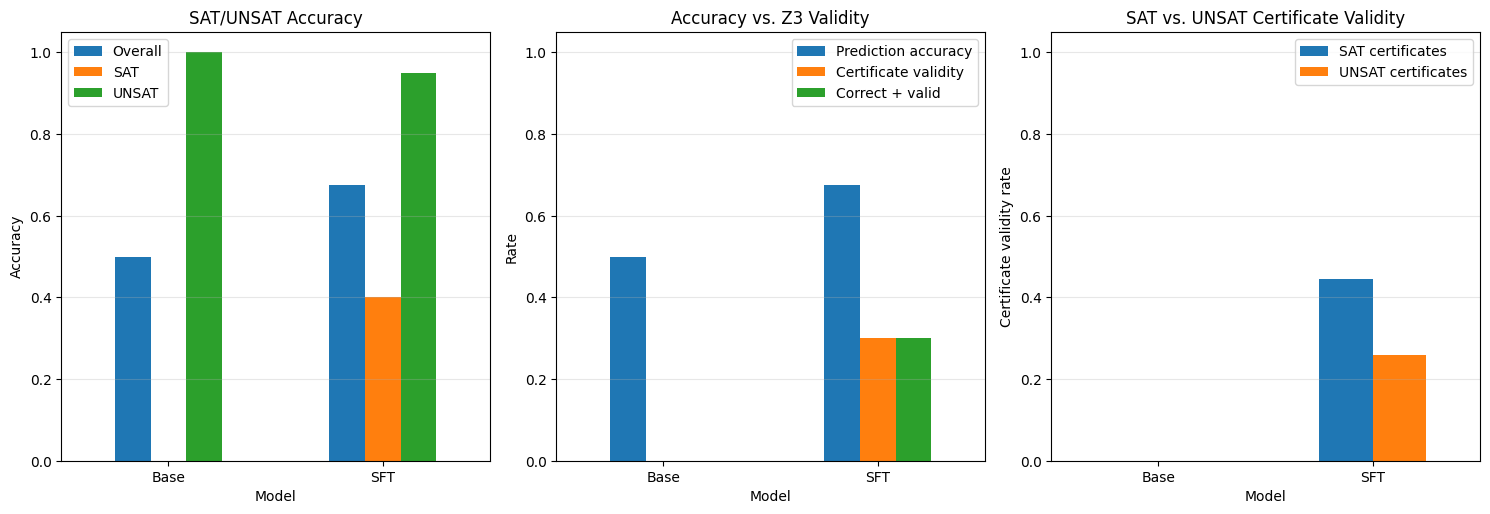

Saved: results/model_comparison_plots/base_vs_sft_three_panel.png


In [17]:
# ============================================================
# Combined comparison plot:
# 1) Overall/SAT/UNSAT accuracy
# 2) Prediction accuracy vs certificate validity
# 3) SAT vs UNSAT certificate validity
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ============================================================
# Subplot 1: Overall, SAT, and UNSAT accuracy
# ============================================================

plot_df1 = accuracy_df.set_index("model")[[
    "overall_accuracy",
    "sat_accuracy",
    "unsat_accuracy",
]]

plot_df1.plot(kind="bar", ax=axes[0])
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("Model")
axes[0].set_title("SAT/UNSAT Accuracy")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(["Overall", "SAT", "UNSAT"])
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].set_box_aspect(1)  # square subplot


# ============================================================
# Subplot 2: Prediction accuracy vs. certificate validity
# ============================================================

plot_df2 = z3_df.set_index("model")[[
    "prediction_accuracy",
    "certificate_validity",
    "correct_and_valid_rate",
]]

plot_df2.plot(kind="bar", ax=axes[1])
axes[1].set_ylabel("Rate")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("Model")
axes[1].set_title("Accuracy vs. Z3 Validity")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(["Prediction accuracy", "Certificate validity", "Correct + valid"])
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].set_box_aspect(1)  # square subplot


# ============================================================
# Subplot 3: SAT vs. UNSAT certificate validity
# ============================================================

plot_df3 = z3_detail_df.set_index("model")[[
    "sat_cert_valid_predicted_sat",
    "unsat_cert_valid_predicted_unsat",
]]

plot_df3.plot(kind="bar", ax=axes[2])
axes[2].set_ylabel("Certificate validity rate")
axes[2].set_ylim(0, 1.05)
axes[2].set_xlabel("Model")
axes[2].set_title("SAT vs. UNSAT Certificate Validity")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(["SAT certificates", "UNSAT certificates"])
axes[2].grid(True, axis="y", alpha=0.3)
axes[2].set_box_aspect(1)  # square subplot


plt.tight_layout()

combined_path = OUTPUT_DIR / "base_vs_sft_three_panel.png"
plt.savefig(combined_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", combined_path)

In [ ]:
import ast
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. File paths
# ============================================================

# Change these if your files are in a different location.
LOG_PATH = Path("results/grpo_z3_qwen35_08b_50sat_50unsat_shortprompt/nohup_GRPO_Train.out")
METRICS_PATH = Path("results/grpo_z3_qwen35_08b_50sat_50unsat_shortprompt/train_metrics.json")

# If you are running this notebook in a folder where you copied the files directly,
# you can instead use:
# LOG_PATH = Path("nohup_GRPO_Train.out")
# METRICS_PATH = Path("GRPO_train_metrics.json")

OUTPUT_DIR = Path("results/grpo_z3_qwen35_08b_50sat_50unsat_shortprompt/plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Parse nohup training log
# ============================================================

def clean_ansi(text: str) -> str:
    """Remove ANSI escape sequences and carriage returns from nohup/tqdm logs."""
    ansi_escape = re.compile(r"\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])")
    text = ansi_escape.sub("", text)
    text = text.replace("\r", "\n")
    return text


def parse_log_dicts(log_path: Path) -> pd.DataFrame:
    """
    Extract Trainer log dictionaries from nohup_GRPO_Train.out.

    The log has lines like:
    {'loss': '0.09118', 'grad_norm': '1.688', ...}
    """
    text = clean_ansi(log_path.read_text(encoding="utf-8", errors="ignore"))

    rows = []
    for line in text.splitlines():
        line = line.strip()

        # Keep only dictionary-looking lines with training metrics.
        if not (line.startswith("{") and line.endswith("}")):
            continue

        try:
            obj = ast.literal_eval(line)
        except Exception:
            continue

        # Keep per-step logs, not just final train_runtime summary.
        if "loss" not in obj:
            continue

        rows.append(obj)

    df = pd.DataFrame(rows)

    # Convert numeric-looking columns to numeric values.
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="ignore")

    # Add step index for plotting.
    df.insert(0, "step", range(1, len(df) + 1))

    return df


log_df = parse_log_dicts(LOG_PATH)

print("Parsed GRPO training steps:", len(log_df))
display(log_df.head())
display(log_df.tail())


# ============================================================
# 3. Load final training metrics
# ============================================================

with METRICS_PATH.open("r", encoding="utf-8") as f:
    final_metrics = json.load(f)

print("Final training metrics:")
print(json.dumps(final_metrics, indent=2))


# ============================================================
# 4. Plot 1: loss, grad norm, and learning rate
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(log_df["step"], log_df["loss"], marker="o")
axes[0].set_title("GRPO Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].set_box_aspect(1)

axes[1].plot(log_df["step"], log_df["grad_norm"], marker="o")
axes[1].set_title("Gradient Norm")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Gradient norm")
axes[1].grid(True, alpha=0.3)
axes[1].set_box_aspect(1)

axes[2].plot(log_df["step"], log_df["learning_rate"], marker="o")
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Learning rate")
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
path = OUTPUT_DIR / "grpo_loss_grad_lr.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)


# ============================================================
# 5. Plot 2: total reward and reward components
# ============================================================

reward_cols = [
    "reward",
    "rewards/format_reward_func/mean",
    "rewards/label_reward_func/mean",
    "rewards/z3_certificate_reward_func/mean",
]

available_reward_cols = [c for c in reward_cols if c in log_df.columns]

plt.figure(figsize=(8, 5))
for col in available_reward_cols:
    plt.plot(log_df["step"], log_df[col], marker="o", label=col)

plt.title("GRPO Reward Components")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

path = OUTPUT_DIR / "grpo_reward_components.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)


# ============================================================
# 6. Plot 3: completion lengths and clipped ratio
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(log_df["step"], log_df["completions/mean_length"], marker="o", label="Mean length")
axes[0].plot(log_df["step"], log_df["completions/max_length"], marker="o", label="Max length")
axes[0].plot(log_df["step"], log_df["completions/min_length"], marker="o", label="Min length")
axes[0].set_title("Completion Lengths")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Tokens")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_box_aspect(1)

axes[1].plot(log_df["step"], log_df["completions/clipped_ratio"], marker="o")
axes[1].set_title("Completion Clipped Ratio")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Clipped ratio")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].set_box_aspect(1)

plt.tight_layout()
path = OUTPUT_DIR / "grpo_completion_lengths_clipping.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)


# ============================================================
# 7. Plot 4: KL, entropy, and step time
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(log_df["step"], log_df["kl"], marker="o")
axes[0].set_title("KL")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("KL")
axes[0].grid(True, alpha=0.3)
axes[0].set_box_aspect(1)

axes[1].plot(log_df["step"], log_df["entropy"], marker="o")
axes[1].set_title("Entropy")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Entropy")
axes[1].grid(True, alpha=0.3)
axes[1].set_box_aspect(1)

axes[2].plot(log_df["step"], log_df["step_time"], marker="o")
axes[2].set_title("Step Time")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Seconds")
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
path = OUTPUT_DIR / "grpo_kl_entropy_step_time.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)


# ============================================================
# 8. Combined 2x2 figure for report
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Loss
axes[0, 0].plot(log_df["step"], log_df["loss"], marker="o")
axes[0, 0].set_title("GRPO Loss")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_box_aspect(1)

# Reward
for col in available_reward_cols:
    axes[0, 1].plot(log_df["step"], log_df[col], marker="o", label=col)
axes[0, 1].set_title("Reward Components")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("Reward")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_box_aspect(1)

# Completion length
axes[1, 0].plot(log_df["step"], log_df["completions/mean_length"], marker="o", label="Mean")
axes[1, 0].plot(log_df["step"], log_df["completions/max_length"], marker="o", label="Max")
axes[1, 0].set_title("Completion Length")
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("Tokens")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_box_aspect(1)

# Clipping
axes[1, 1].plot(log_df["step"], log_df["completions/clipped_ratio"], marker="o")
axes[1, 1].set_title("Clipped Completion Ratio")
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("Ratio")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_box_aspect(1)

plt.tight_layout()
path = OUTPUT_DIR / "grpo_training_summary_2x2.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)


# ============================================================
# 9. Save parsed table and print concise statistics
# ============================================================

parsed_csv_path = OUTPUT_DIR / "parsed_grpo_training_log.csv"
log_df.to_csv(parsed_csv_path, index=False)
print("Saved parsed log:", parsed_csv_path)

summary = {
    "num_steps": int(len(log_df)),
    "final_train_loss": float(final_metrics.get("train_loss")),
    "train_runtime_min": float(final_metrics.get("train_runtime")) / 60,
    "train_samples_per_second": float(final_metrics.get("train_samples_per_second")),
    "train_steps_per_second": float(final_metrics.get("train_steps_per_second")),
    "mean_reward": float(log_df["reward"].mean()) if "reward" in log_df else None,
    "final_reward": float(log_df["reward"].iloc[-1]) if "reward" in log_df else None,
    "mean_completion_length": float(log_df["completions/mean_length"].mean()) if "completions/mean_length" in log_df else None,
    "mean_clipped_ratio": float(log_df["completions/clipped_ratio"].mean()) if "completions/clipped_ratio" in log_df else None,
    "mean_z3_reward": float(log_df["rewards/z3_certificate_reward_func/mean"].mean()) if "rewards/z3_certificate_reward_func/mean" in log_df else None,
}

print("\nConcise GRPO training summary:")
print(json.dumps(summary, indent=2))